In [ ]:
# Handwritten Digit Compression

compressed shape: (60000, 50)
Reconstruction Error (Train): 0.011793
Reconstruction Error (Test): 0.011485


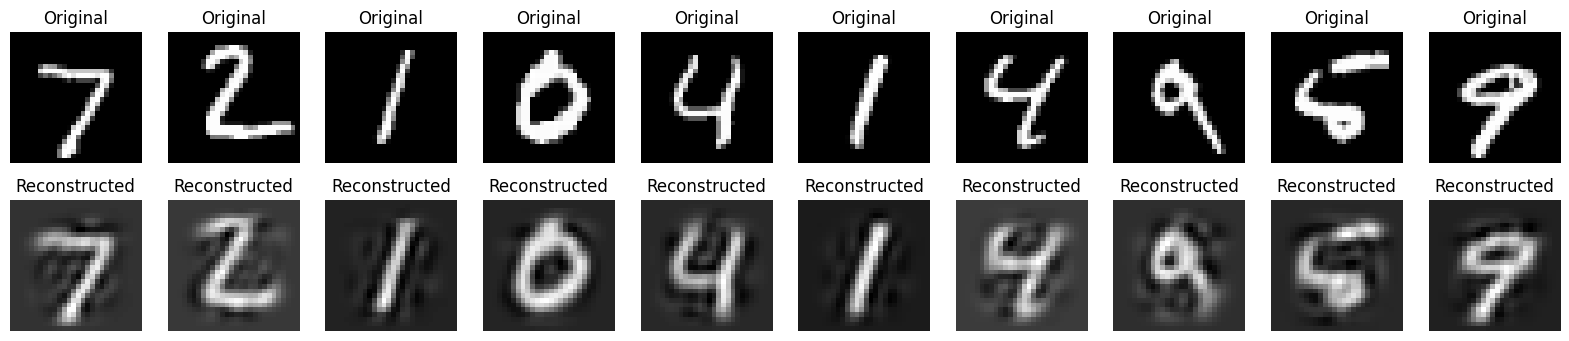

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, mean_squared_error

# load dataset

train = pd.read_csv("mnist_train.csv ")
test = pd.read_csv("mnist_test.csv ")

# seperate tha label and pixels

x_train = train.drop("label", axis = 1).values
y_train = train["label"].values

x_test = test.drop("label", axis = 1).values
y_test = test["label"].values

# normzilers the pixel values 

x_train = x_train/255.0
x_test = x_test/255.0

# apply pca

model = PCA(n_components = 50)
x_train_pca = model.fit_transform(x_train)
x_test_pca = model.transform(x_test)

print("compressed shape:",x_train_pca.shape)

# reconstruct pexiel from pca

x_recon_train = model.inverse_transform(x_train_pca)
x_recon_test = model.inverse_transform(x_test_pca)


# measure reconstruction error

train_error = mean_squared_error(x_recon_train, x_train)
test_error = mean_squared_error(x_recon_test, x_test)

print(f"Reconstruction Error (Train): {train_error:.6f}")
print(f"Reconstruction Error (Test): {test_error:.6f}")


# Visualize original vs reconstructed images
def plot_comparison(original, reconstructed, n=10):
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original[i].reshape(28, 28), cmap="gray")
        plt.title("Original")
        plt.axis("off")

        # Reconstructed
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
        plt.title("Reconstructed")
        plt.axis("off")
    plt.show()

plot_comparison(x_test, x_recon_test, n=10)


In [ ]:
# Social Media Behavior Analysis

[0.57761901 0.42238099]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


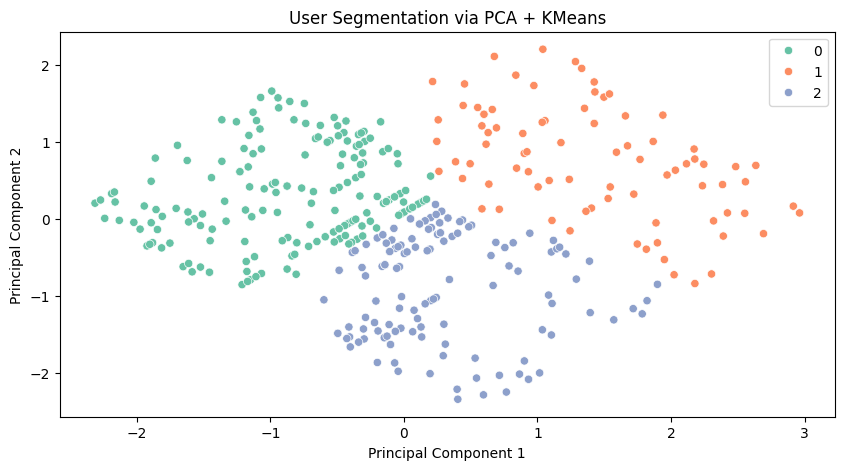

               Age  EstimatedSalary
cluster                            
0        28.944134     56491.620112
1        42.469880    121903.614458
2        46.057971     55557.971014


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns

# load the dataset

data = pd.read_csv("Social_Network_Ads.csv")

features = data[["Age", "EstimatedSalary"]]

# scaling

scaling = StandardScaler()
x_scaling = scaling.fit_transform(features)

# appling pca

pca = PCA(n_components = 2)
x_pca = pca.fit_transform(x_scaling)
print(pca.explained_variance_ratio_)

# apply cluster  kmeans

kmean = KMeans(n_clusters = 3, random_state = 42)
clusters = kmean.fit_predict(x_pca)

# adding cluster label

data['cluster'] = clusters

# vasulization

plt.figure(figsize = [10, 5])
sns.scatterplot(x = x_pca[:,0], y = x_pca[:,1], hue= clusters,palette = "Set2")
plt.title("User Segmentation via PCA + KMeans")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

print(data.groupby('cluster')[['Age', 'EstimatedSalary']].mean())

